In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

import tqdm
import glob
import re
import pickle
import os
from typing import List
import seaborn as sns
#sns.set() #推奨されないみたい
sns.set_style("white"+"grid")
sns.set_palette("Paired")
import time

plt.rcParams['font.family'] = 'Times New Roman' # Fonts
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 24 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 20 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 20 # 軸だけ変更されます
color_arr=plt.rcParams['axes.prop_cycle'].by_key()['color']

#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
def isFloat(s:str)->bool:
    try:
        float(s)
        return True
    except:
        return False
    
def fix_parameter_line_to_dict(parameter_string:str):
    response={}
    key=""
    for x in parameter_string.split("_"):
        if not isFloat(x):
            if not '~' in x:
                if key!="":
                    key+="_"
                key+=x
            else:
                list_param=x.split('~')
                if len(list_param)>2:
                    response[list_param[0]]=','.join(list_param[1:-1])
        else:
            response[key]=float(x)
            key=""
    return response

In [28]:
dim="2dp"
noatk_name=f"checkLTA"+dim
fname=f"sim_LTA_{2}.csv"
if dim=="2d":
    fname=f"sim_LTA_{7}.csv"
if dim=="2dp":
    fname=f"sim_LTA_{3}.csv"
    
noatk=pd.read_csv(f"data/{noatk_name}/{fname}",skiprows=1)
with open(f"data/{noatk_name}/{fname}") as f:
    parameter_line=f.readline()
response=fix_parameter_line_to_dict(parameter_line)
print(noatk["last_true_broadcast"].mean(),len(noatk[noatk["last_true_broadcast"]>50800]))
print(response["TA"])
noatk

81560.68 99
2000,2000,500,500


,seed,Mtype,time,first_true_receive,first_fake_receive,last_true_receive,last_fake_receive,first_true_broadcast,first_fake_broadcast,last_true_broadcast,last_fake_broadcast,none,true,fake,double,trueMax,fakeMax,connect,broadcast,malicious_broadcast,true_broadcast,fake_broadcast,true_trust_node,fake_trust_node,true_broadcast_node,fake_broadcast_node,RAin,RAinWoAtk,TAin,TAinTimeMean,TAinTimeStd
0,1,1,100000,50095,0,99996,0,50000,0,100000,0,735,83,0,0,90,0,177590,412254,0,412254,0,978,0,978,-1,0,0,1000,50.0330,48.6436
1,2,1,100000,50487,0,99982,0,50000,0,100000,0,730,61,0,0,92,0,191460,410417,0,410417,0,979,0,979,-1,0,0,1007,49.6083,46.4474
2,3,1,100000,50000,0,67290,0,50000,0,67577,0,823,0,0,0,95,0,69437,156730,0,156730,0,373,0,373,-1,0,0,1030,48.5588,51.2769
3,4,1,100000,50098,0,99986,0,50000,0,100000,0,721,63,0,0,88,0,191051,393129,0,393129,0,958,0,958,-1,0,0,983,50.9022,53.2135
4,5,1,100000,50154,0,83551,0,50000,0,83904,0,808,0,0,0,95,0,134160,277742,0,277742,0,663,0,663,-1,0,0,999,50.0802,53.0910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,1,100000,50147,0,66077,0,50000,0,66487,0,788,0,0,0,94,0,70900,141727,0,141727,0,335,0,335,-1,0,0,1005,49.7709,51.8291
96,97,1,100000,50157,0,59958,0,50000,0,60398,0,782,0,0,0,95,0,49317,84836,0,84836,0,201,0,201,-1,0,0,965,51.7282,55.0280
97,98,1,100000,50000,0,99991,0,50000,0,100000,0,723,70,0,0,95,0,205608,419304,0,419304,0,991,0,991,-1,0,0,1018,49.1436,50.4914
98,99,1,100000,50092,0,84633,0,50000,0,84897,0,784,0,0,0,102,0,154406,308622,0,308622,0,721,0,721,-1,0,0,1063,47.0650,46.0225


<Axes: >

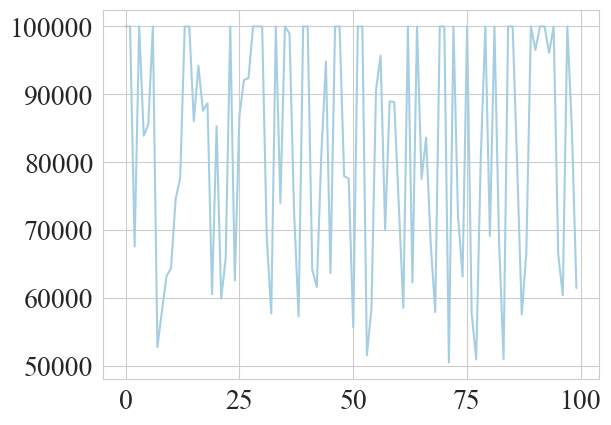

In [29]:
noatk["last_true_broadcast"].plot()

In [30]:
results=[]
folder=f"methodCmp{dim}"+""
files=glob.glob(f"data/{folder}/*")
for f in files:
    df=pd.read_csv(f,skiprows=1)
    with open(f) as f:
        parameter_line=f.readline()
    response=fix_parameter_line_to_dict(parameter_line)
    response["fTAsize"]=float(response["fTA"].split(",")[-1])
    response["length"]=len(df)
    response["mean_broadcast_duration_noatk"]=noatk[df["last_fake_broadcast"]>0][["last_true_broadcast","last_fake_broadcast"]].max(axis=1).mean()
    response["mean_broadcast_duration_with_atk"]=df[df["last_fake_broadcast"]>0][["last_true_broadcast","last_fake_broadcast"]].max(axis=1).mean()
    response["attack_success_ratio"]=sum(df["last_fake_broadcast"]>0)/len(df)
    results.append(response)

In [31]:
folder=f"methodCmp{dim}"+""
fname=f"sim_LTA_{0}_LfTA_{0}.csv"
df=pd.read_csv(f"data/{folder}/{fname}",skiprows=1)
with open(f"data/{folder}/{fname}") as f:
    parameter_line=f.readline()
response=fix_parameter_line_to_dict(parameter_line)
print(response["TA"])
df

2000,2000,500,500


,seed,Mtype,time,first_true_receive,first_fake_receive,last_true_receive,last_fake_receive,first_true_broadcast,first_fake_broadcast,last_true_broadcast,last_fake_broadcast,none,true,fake,double,trueMax,fakeMax,connect,broadcast,malicious_broadcast,true_broadcast,fake_broadcast,true_trust_node,fake_trust_node,true_broadcast_node,fake_broadcast_node,RAin,RAinWoAtk,TAin,TAinTimeMean,TAinTimeStd
0,1,7,100000,50095,55279,99996,55443,50000,55279,100000,55520,735,83,0,0,90,1,177870,412259,242,412259,0,978,0,978,0,0,0,1001,49.9830,48.5787
1,2,7,100000,50487,55247,99982,55701,50000,55247,100000,55703,730,61,0,0,92,3,191699,410425,274,410112,313,979,2,979,2,0,0,1008,49.5591,46.4281
2,3,7,100000,50000,55240,67290,55630,50000,55240,67577,55630,823,0,0,0,95,2,69703,156738,281,156655,83,373,1,373,1,0,0,1031,48.5117,51.2612
3,4,7,100000,50098,55070,99986,55566,50000,55070,100000,55566,721,63,0,0,88,2,191241,393136,451,393134,2,958,1,958,1,0,0,984,50.8505,53.2100
4,5,7,100000,50154,55020,83551,55612,50000,55020,83904,55616,808,0,0,0,95,2,134381,277747,501,277742,5,663,1,663,1,0,0,1000,50.0300,53.0681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,7,100000,50147,55048,66077,55621,50000,55048,66487,55621,788,0,0,0,94,2,71244,141738,473,141674,64,335,1,335,1,0,0,1006,49.7214,51.8266
96,97,7,100000,50157,55232,59958,55597,50000,55232,60398,55597,782,0,0,0,95,3,49518,84841,289,84618,223,201,5,201,5,0,0,966,51.6746,55.0200
97,98,7,100000,50000,55035,99991,55540,50000,55035,100000,55676,723,70,0,0,95,2,206020,419318,486,419181,137,991,1,991,1,0,0,1019,49.0953,50.4727
98,99,7,100000,50092,55020,84633,55341,50000,55020,84897,55520,784,0,0,0,102,1,154518,308629,501,308629,0,721,0,721,0,0,0,1064,47.0207,45.9769


In [32]:
float(response["fTA"].split(",")[-1])

10.0

noatk 83422.65957446808 94
df 82291.37234042553 55624.10638297872
sub -1107.8617021276586


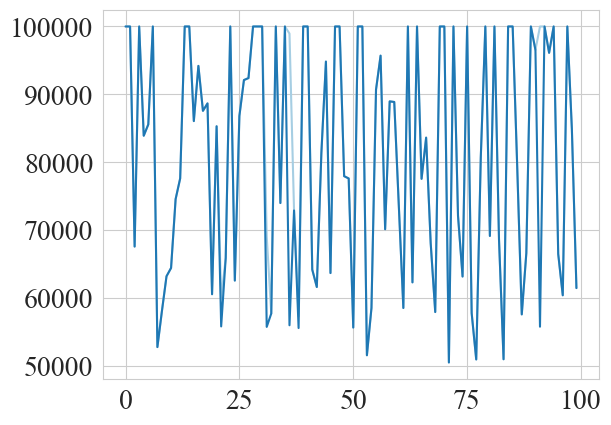

In [33]:
print("noatk",noatk[df["last_fake_broadcast"]>0]["last_true_broadcast"].mean(),sum(df["last_fake_broadcast"]>0))
print("df",df[df["last_fake_broadcast"]>0]["last_true_broadcast"].mean(),df[df["last_fake_broadcast"]>0]["last_fake_broadcast"].mean())
print("sub",df[df["last_fake_broadcast"]>0][["last_true_broadcast","last_fake_broadcast"]].max(axis=1).mean()-noatk[df["last_fake_broadcast"]>0]["last_true_broadcast"].mean())
plt.plot(noatk["last_true_broadcast"])
plt.plot(df["last_true_broadcast"])

In [24]:
print("noatk:",noatk["last_true_broadcast"].mean())
print("true recov:",len(df[(df["last_true_broadcast"]>df["last_fake_broadcast"]) & (df["last_fake_broadcast"]>0)]),df[(df["last_true_broadcast"]>df["last_fake_broadcast"]) & (df["last_fake_broadcast"]>0)]["last_true_broadcast"].mean())
print("fake over:",len(df[df["last_true_broadcast"]<df["last_fake_broadcast"]]),df[df["last_true_broadcast"]<df["last_fake_broadcast"]]["last_fake_broadcast"].mean() ,"fake fail:",len(df[df["last_fake_broadcast"]==0.0]))
df[df["last_true_broadcast"]<df["last_fake_broadcast"]]

noatk: 81374.24
true recov: 85 85154.22352941177
fake over: 4 55972.25 fake fail: 11


,seed,Mtype,time,first_true_receive,first_fake_receive,last_true_receive,last_fake_receive,first_true_broadcast,first_fake_broadcast,last_true_broadcast,last_fake_broadcast,none,true,fake,double,trueMax,fakeMax,connect,broadcast,malicious_broadcast,true_broadcast,fake_broadcast,true_trust_node,fake_trust_node,true_broadcast_node,fake_broadcast_node,RAin,RAinWoAtk,TAin,TAinTimeMean,TAinTimeStd
26,27,7,100000,50000,55150,55872,56345,50000,55150,55872,56354,132,0,0,0,52,27,36289,40276,271,35637,4639,111,31,111,31,0,0,1020,48.9912,49.2797
45,46,7,100000,50035,55020,55333,55634,50000,55020,55333,55851,104,0,0,0,43,14,18298,31200,401,29913,1287,84,13,84,13,0,0,1021,49.0118,53.0764
70,71,7,100000,50000,55106,55442,55648,50000,55106,55628,55726,104,0,0,0,54,6,34018,36659,315,36181,478,102,5,102,5,0,0,1026,48.6780,52.8439
88,89,7,100000,50051,55020,55531,55749,50000,55020,55531,55958,104,0,0,0,64,7,48348,46932,401,46087,845,129,6,129,6,0,0,1012,49.4045,50.7519


27334.966587112172 17 419 56696.708 68150.059


(array([21., 14., 30., 31., 53., 50., 52., 38., 45., 85.]),
 array([    0. ,  4497.3,  8994.6, 13491.9, 17989.2, 22486.5, 26983.8,
        31481.1, 35978.4, 40475.7, 44973. ]),
 <BarContainer object of 10 artists>)

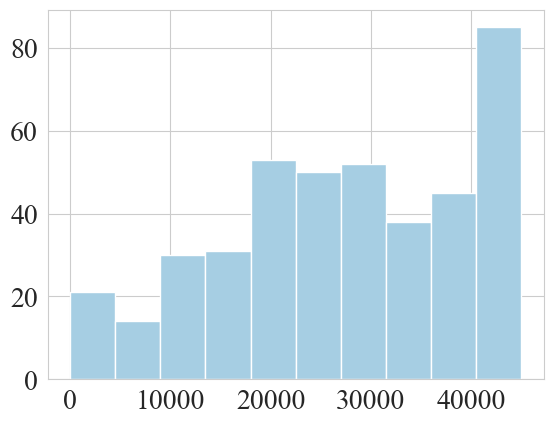

In [282]:
vals=(df[df["last_fake_broadcast"]>0][["last_true_broadcast","last_fake_broadcast"]].max(axis=1)-noatk[df["last_fake_broadcast"]>0]["last_true_broadcast"]).values
print(np.mean(vals),len([x for x in vals if x==0]),len(vals),noatk["last_true_broadcast"].mean(),df[["last_true_broadcast","last_fake_broadcast"]].max(axis=1).mean())
plt.hist(vals)


In [337]:
def get_parameter_list_dict(df:pd.DataFrame,parameter_key) -> dict:
    parameter_list_dict={}
    df[parameter_key[0]].unique().sort()
    for i in parameter_key:
        unique_parameter_values=df[i].unique()
        if len(unique_parameter_values)>1:
            parameter_list_dict[i]=np.sort(unique_parameter_values)
    return parameter_list_dict

def get_parameter_sets(arg_df:pd.DataFrame,columns):
    """
    DataFrameに含まれるパラメータの組み合わせを返す関数
    
    :param pd.DataFrame arg_df: パラメータを探索する対象のdf
    :param list[str] columns: パラメータを探索するカラムのリスト
    :return restrictions: パラメータの組み合わせをまとめたdictのlist 
    """
    restrictions=[]
    def get_restrictions(arg_df:pd.DataFrame,columns,columns_index=0,restriction={}):
        if columns_index==0:
            restriction={}
        if len(arg_df[columns[columns_index]].unique())>0:
            for i in arg_df[columns[columns_index]].unique():
                restriction[columns[columns_index]]=i
                if columns_index==len(columns)-1:
                    restrictions.append(restriction.copy())
                else:
                    get_restrictions(arg_df[(arg_df[columns[columns_index]]==i)],columns,columns_index+1,restriction)
    get_restrictions(arg_df,columns)
    return restrictions

In [384]:
dim="2d"
noatk_name=f"checkLambda"+dim
fname=f"sim_lambda_{2}.csv"
if dim=="2d":
    fname=f"sim_lambda_{7}.csv"

noatk=pd.read_csv(f"data/{noatk_name}/{fname}",skiprows=1)
with open(f"data/{noatk_name}/{fname}") as f:
    parameter_line=f.readline()
response=fix_parameter_line_to_dict(parameter_line)
print(noatk["last_true_broadcast"].mean(),len(noatk[noatk["last_true_broadcast"]>50800]))
print(response["Lambda"])
noatk

results=[]
folder=f"methodCmp{dim}L2"+""
files=glob.glob(f"data/{folder}/*")
for f in files:
    df=pd.read_csv(f,skiprows=1)
    with open(f) as f:
        parameter_line=f.readline()
    response=fix_parameter_line_to_dict(parameter_line)
    response["fTAsize"]=float(response["fTA"].split(",")[-1])
    response["length"]=len(df)
    response["mean_broadcast_duration_noatk"]=noatk[df["last_fake_broadcast"]>0][["last_true_broadcast","last_fake_broadcast"]].max(axis=1).mean()-noatk[df["last_fake_broadcast"]>0]["first_true_broadcast"].mean()
    response["mean_broadcast_duration_with_atk"]=df[df["last_fake_broadcast"]>0][["last_true_broadcast","last_fake_broadcast"]].max(axis=1).mean()-df[df["last_fake_broadcast"]>0]["first_true_broadcast"].mean()
    response["mean_broadcast_noatk"]=noatk[df["last_fake_broadcast"]>0]["broadcast"].mean()
    response["mean_broadcast_with_atk"]=df[df["last_fake_broadcast"]>0]["broadcast"].mean()
    response["attack_success_ratio"]=sum(df["last_fake_broadcast"]>0)/len(df)
    results.append(response)

df=pd.DataFrame(results)
df

56696.708 922
0.002


,Lambda,Vm,Vw,fVm,Slp,Cr,Pt,Nx,Ny,XL,YL,malicious_appear_time,malicious_appear_interval,malicious_appear_num,malicious_appear_type,Method,Start,Attack,malicious_fake_id,distinct_fake,consider_all_TA,fix_field,use_diff_lambda,simulation_max_loop,TA,fTA,fTAsize,length,mean_broadcast_duration_noatk,mean_broadcast_duration_with_atk,mean_broadcast_noatk,mean_broadcast_with_atk,attack_success_ratio
0,0.002,1.0,0.0,1.0,0.0,20.0,0.5,4.0,4.0,4000.0,4000.0,5000.0,0.0,1.0,1.0,9.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,50000.0,"2000,2000,800,800","2000,2000,10,10",10.0,1000,11662.582339,6987.362768,55462.71599,3.100959e+04,0.419
1,0.002,1.0,0.0,1.0,0.0,20.0,0.5,4.0,4.0,4000.0,4000.0,5000.0,0.0,1.0,1.0,21.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,50000.0,"2000,2000,800,800","2000,2000,3200,3200",3200.0,1000,11662.582339,35091.680191,55462.71599,1.408305e+06,0.419
2,0.002,1.0,0.0,1.0,0.0,20.0,0.5,4.0,4.0,4000.0,4000.0,5000.0,0.0,1.0,1.0,24.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,50000.0,"2000,2000,800,800","2000,2000,10,10",10.0,1000,11662.582339,11213.331742,55462.71599,5.294845e+04,0.419
3,0.002,1.0,0.0,1.0,0.0,20.0,0.5,4.0,4.0,4000.0,4000.0,5000.0,0.0,1.0,1.0,12.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,50000.0,"2000,2000,800,800","2000,2000,1600,1600",1600.0,1000,11662.582339,19182.801909,55462.71599,1.328560e+05,0.419
4,0.002,1.0,0.0,1.0,0.0,20.0,0.5,4.0,4.0,4000.0,4000.0,5000.0,0.0,1.0,1.0,24.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,50000.0,"2000,2000,800,800","2000,2000,1600,1600",1600.0,1000,11662.582339,23445.319809,55462.71599,1.851805e+05,0.419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,0.002,1.0,0.0,1.0,0.0,20.0,0.5,4.0,4.0,4000.0,4000.0,5000.0,0.0,1.0,1.0,9.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,50000.0,"2000,2000,800,800","2000,2000,1600,1600",1600.0,1000,11662.582339,15469.718377,55462.71599,8.803711e+04,0.419
106,0.002,1.0,0.0,1.0,0.0,20.0,0.5,4.0,4.0,4000.0,4000.0,5000.0,0.0,1.0,1.0,21.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,50000.0,"2000,2000,800,800","2000,2000,800,800",800.0,1000,11662.582339,12078.035800,55462.71599,5.748588e+04,0.419
107,0.002,1.0,0.0,1.0,0.0,20.0,0.5,4.0,4.0,4000.0,4000.0,5000.0,0.0,1.0,1.0,21.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,50000.0,"2000,2000,800,800","2000,2000,2400,2400",2400.0,1000,11662.582339,34239.873508,55462.71599,1.100777e+06,0.419
108,0.002,1.0,0.0,1.0,0.0,20.0,0.5,4.0,4.0,4000.0,4000.0,5000.0,0.0,1.0,1.0,12.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,50000.0,"2000,2000,800,800","2000,2000,800,800",800.0,1000,11662.582339,12078.035800,55462.71599,5.748588e+04,0.419


noAtk val : 55462.72
[  10.  200.  400.  600.  800. 1200. 1600. 2400. 3200. 4000.]
3.0 [  51105.43198091   51307.55369928   51554.02625298   52151.24343675
   57485.87828162  173944.27923628  346966.66587112 2044964.90453461
 2831709.3221957  6025985.8973747 ]
1.0 [  43392.34128878   42024.9522673    41156.39140811   44237.11217184
   57485.87828162  234668.33890215  438876.12649165 2232695.64439141
 3006858.09546539 6207932.78281623]
5.0 [  52948.45346062   52950.68973747   52998.8902148    52998.97852029
   57485.87828162  123771.46062053  185180.54892601 1256504.03579952
 1728848.50119332 4286313.14797136]
8.0 [ 31009.59427208  32261.49403341  41025.97613365  47534.150358
  57485.87828162  83369.87828162  88037.1097852  118921.25775656
 142280.97136038 240777.06443914]
9.0 [ 31009.59427208  32261.49403341  41025.97613365  47534.150358
  57485.87828162  83369.87828162  88037.1097852  118921.25775656
 142280.97136038 240777.06443914]
12.0 [ 51595.54176611  51407.8424821   51675.560859

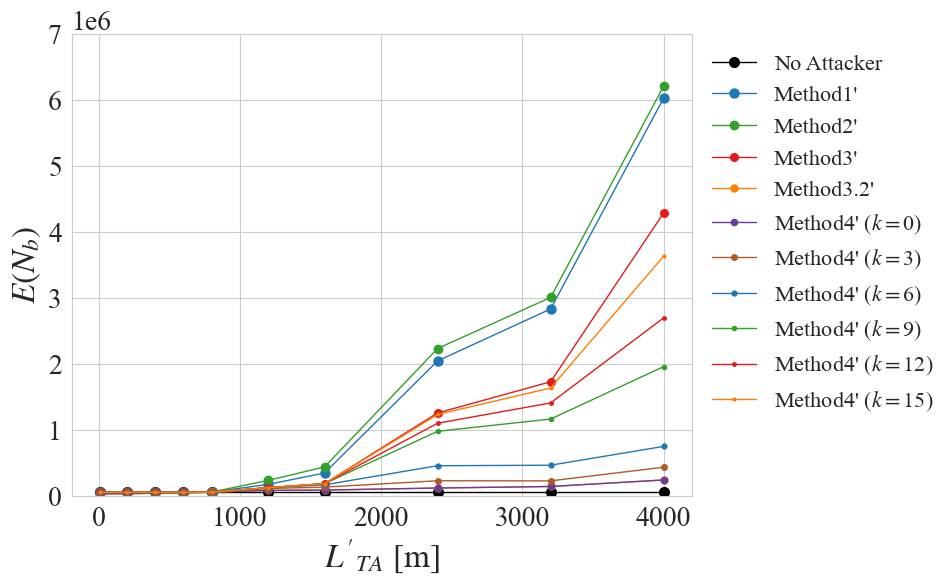

In [385]:
label_dict={
    "Method":{1.0:"Method2", 3.0:"Method1", 5.0:"Method3", 7.0:"Method5", 8.0:"Method3.2"} # Method2 : New, Method1 : Old, Method3: Times
}
label_name = {
    'Lambda':r'$\lambda$',
    'malicious_appear_interval':r'$t_{interval} [s]$',
    'malicious_appear_num':r'$N_{attacker}$',
    'malicious_appear_type':r'$Appear Type$',
    'fTAsize':r"$L'_{TA}$ [m]"
}

X="fTAsize"
#X="malicious_appear_interval"
Y="mean_broadcast_duration_with_atk"
Y="mean_broadcast_with_atk"
L="Method"


df_name=folder
columns=list(df.columns)
parameter_list_dict = get_parameter_list_dict(df,parameter_key=columns[:columns.index("length")])
if (1.0 in parameter_list_dict["Method"]) and (3.0 in parameter_list_dict["Method"]):
    parameter_list_dict["Method"] = [3.0,1.0] + [x for x in parameter_list_dict["Method"] if x not in [1.0,3.0]]
if 7.0 in parameter_list_dict["Method"]:
    parameter_list_dict["Method"] = [x for x in parameter_list_dict["Method"] if x!=7.0]#+[7.0]

Lambda = df["Lambda"].unique()[0]

lock = {
    #"malicious_appear_type":parameter_list_dict["malicious_appear_type"][0],
    #"malicious_appear_interval":parameter_list_dict["malicious_appear_interval"][0],
    #"malicious_appear_num":parameter_list_dict["malicious_appear_num"][0],
    #"fTAsize":parameter_list_dict["fTAsize"][2],
    }
if X in lock.keys():
    lock.pop(X)

fig=plt.figure(figsize=(8,6))
axe=fig.add_subplot(111)
marker_size=7.0;line_width=2.0;color_arr_i=1

noAtk_val=df[Y[:-8]+"noatk"].values[0]
print(f"noAtk val : {noAtk_val:.2f}")
x=parameter_list_dict[X]
print(x)
line_width=1.0
marker_size=7.0;color_arr_i=1
axe.plot(x,[noAtk_val]*len(x),marker="o",
            markersize=marker_size,linewidth=line_width,
            color="k",
            label=f"No Attacker")
marker_size-=0.5

cond = True
for k,v in lock.items():
    cond = cond & (df[k]==v)

plot_df=df[(df["Lambda"]==Lambda) & (cond)].sort_values(X)

for l in parameter_list_dict[L]:
    y=plot_df[(plot_df[L]==l)][Y]
    print(l,y.values)
    if l in label_dict[L].keys():
        label=f"{label_dict[L][l]}'"+("'" if "v2" in df_name else "")
        if 1:
            axe.plot(x,y,marker="o",
                    markersize=marker_size,linewidth=line_width,
                    color=color_arr[color_arr_i],
                    label=label
            )
            color_arr_i=(color_arr_i+2)%len(color_arr)+(0 if color_arr_i<len(color_arr) else 1)
            marker_size-=0.5
            
    else:
        label=f"Method4'"+("'" if "v2" in df_name else "")+" ("+r"$k=$"+f"{l-9.0:.0f})"
        axe.plot(x,y,marker="o",
                markersize=marker_size,linewidth=line_width,
                color=color_arr[color_arr_i],
                label=label
        )
        color_arr_i=(color_arr_i+2)%len(color_arr)+(0 if color_arr_i<len(color_arr) else 1)
        marker_size-=0.5

if Y=="mean_broadcast_duration" or Y=="mean_broadcast_duration_with_atk":
    axe.set_ylim(0,52000)
    axe.set_ylabel(r"$E(T_{f})$ [s]")
if Y=="mean_true_broadcast_duration":
    axe.set_ylim(0,52000)
    axe.set_ylabel(r"$E(T_{f_{true}})$ [s]")
if Y=="mean_broadcast" or Y=="mean_broadcast_with_atk":
    axe.set_ylim(0,7*1e6)
    #axe.set_xticks([1000,2000,3000,4000])
    axe.set_ylabel(r"$E(N_{b})$")
if "result" in Y:
    if "ratio" in Y:
        axe.set_ylim(0,1.05)
    else:
        axe.set_ylim(0,1050)
    axe.set_label(r"$fail$")

axe.set_xlabel(label_name[X])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=16, frameon=False)
print(lock)
if 1:
    os.makedirs(f"fig/rep20251127-L2/",exist_ok=True)
    fig.savefig(f"fig/rep20251127-L2/{Y}_{X}_{folder}.png", bbox_inches="tight", pad_inches=0.05)